In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Colab_Notebooks'
os.chdir(project_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -r requirements.txt

In [3]:
import os, time, torch, numpy as np, pandas as pd
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback, AutoConfig, AutoTokenizer
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from model_utils import (
    CustomClassifier, compute_metrics,
    save_model_pickle, load_model_pickle,
    export_epoch_metrics, plot_confusion,
    evaluate_model, test_plot_confusion_matrix
)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("models", exist_ok=True)

In [5]:
train_csv = 'train_binary_balanced.csv'
val_csv   = 'validation_binary_preprocessed.csv'

df_tr, df_val = pd.read_csv(train_csv), pd.read_csv(val_csv)
df_tr = df_tr[df_tr.tweet_soft.notna()]; df_val = df_val[df_val.tweet_soft.notna()]

tokenizer_distil = AutoTokenizer.from_pretrained("distilroberta-base")
tokenizer_roberta = AutoTokenizer.from_pretrained("roberta-base")

def tok_distil(ex): return tokenizer_distil(ex['tweet_soft'], padding='max_length', truncation=True, max_length=128)
def tok_roberta(ex): return tokenizer_roberta(ex['tweet_soft'], padding='max_length', truncation=True, max_length=128)

new_tr_distil = Dataset.from_pandas(df_tr[['tweet_soft','label']]).map(tok_distil, batched=True).remove_columns('tweet_soft').rename_column('label','labels')
new_val_distil = Dataset.from_pandas(df_val[['tweet_soft','label']]).map(tok_distil, batched=True).remove_columns('tweet_soft').rename_column('label','labels')

new_tr_roberta = Dataset.from_pandas(df_tr[['tweet_soft','label']]).map(tok_roberta, batched=True).remove_columns('tweet_soft').rename_column('label','labels')
new_val_roberta = Dataset.from_pandas(df_val[['tweet_soft','label']]).map(tok_roberta, batched=True).remove_columns('tweet_soft').rename_column('label','labels')


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/34791 [00:00<?, ? examples/s]

Map:   0%|          | 0/7106 [00:00<?, ? examples/s]

Map:   0%|          | 0/34791 [00:00<?, ? examples/s]

Map:   0%|          | 0/7106 [00:00<?, ? examples/s]

In [6]:
labels = df_tr.label.tolist()
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
weights = torch.tensor(cw, dtype=torch.float).to(device)
num_labels = len(np.unique(labels))

In [7]:
args = TrainingArguments(
          output_dir="models",
          per_device_train_batch_size=32,
          per_device_eval_batch_size=64,
          learning_rate=3e-4,
          weight_decay=0.005,
          warmup_ratio=0.1,
          lr_scheduler_type='cosine',
          num_train_epochs=10,

            # → evaluation on validation every epoch
          eval_strategy="epoch",
          save_strategy="epoch",
          save_total_limit=1,

          load_best_model_at_end=True,
          metric_for_best_model="f1",

          remove_unused_columns=False,
          fp16=torch.cuda.is_available(),
          gradient_accumulation_steps=2,
          optim='adamw_torch_fused',
          report_to="none"
        )

<ipython-input-8-b0086acbb74f>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_distil = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,0.710500,0.190957,0.923726,0.852429,0.917357,0.879467,"[[1129, 115], [427, 5435]]"
2,0.360600,0.200935,0.921053,0.845801,0.933151,0.879373,"[[1184, 60], [501, 5361]]"
3,0.302400,0.176313,0.933999,0.871552,0.919784,0.892869,"[[1117, 127], [342, 5520]]"
4,0.261900,0.192039,0.935547,0.872260,0.928005,0.896404,"[[1140, 104], [354, 5508]]"
5,0.232700,0.168339,0.940051,0.880770,0.930418,0.902719,"[[1139, 105], [321, 5541]]"


training time of DistilRoberta is: 7.49 min


<Figure size 1000x800 with 0 Axes>

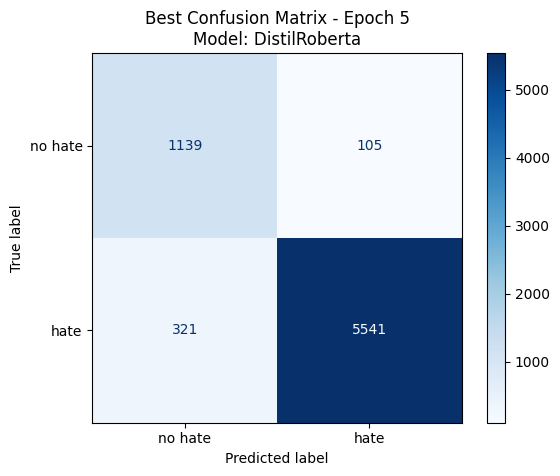

In [8]:
config = AutoConfig.from_pretrained("distilroberta-base", num_labels=num_labels)
model = CustomClassifier("distilroberta-base", config, class_weights=weights).to(device)

trainer_distil = Trainer(
          model=model, args=args,
          train_dataset=new_tr_distil, eval_dataset=new_val_distil,
          tokenizer=tokenizer_distil, data_collator=DataCollatorWithPadding(tokenizer_distil),
          compute_metrics=compute_metrics,
          callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)]
  )

result = trainer_distil.train()

time = round(result.metrics['train_runtime'] / 60,2)
print(f"training time of DistilRoberta is: {time} min")

best_model = trainer_distil.model
best_model_dir = os.path.join("models", "Distil_binary")
os.makedirs(best_model_dir, exist_ok=True)
os.rename(trainer_distil.state.best_model_checkpoint, best_model_dir)

save_model_pickle(best_model, best_model_dir, tokenizer_distil)

logs = pd.DataFrame(trainer_distil.state.log_history)
plot_confusion(logs, num_labels, "DistilRoberta")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-9-51dd79abb584>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_roberta = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,0.767800,0.190043,0.929637,0.865563,0.909857,0.885300,"[[1094, 150], [350, 5512]]"
2,0.375300,0.166086,0.936673,0.877516,0.918872,0.896177,"[[1109, 135], [315, 5547]]"
3,0.295800,0.176062,0.937658,0.877365,0.925485,0.898693,"[[1128, 116], [327, 5535]]"
4,0.257800,0.177195,0.937518,0.874234,0.934898,0.900180,"[[1158, 86], [358, 5504]]"


training time of Roberta is: 11.43 min 


<Figure size 1000x800 with 0 Axes>

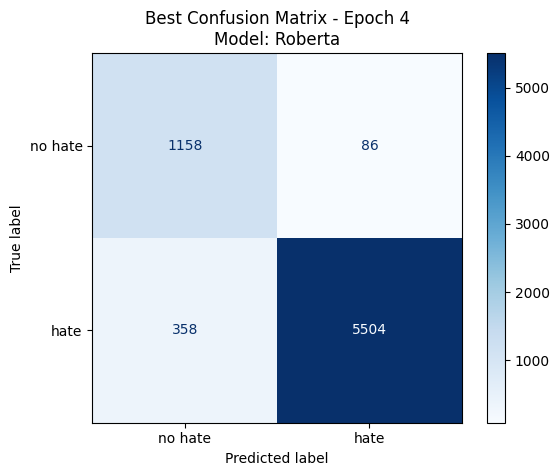

In [9]:
config = AutoConfig.from_pretrained("roberta-base", num_labels=num_labels)
model = CustomClassifier("roberta-base", config, class_weights=weights).to(device)

trainer_roberta = Trainer(
          model=model, args=args,
          train_dataset=new_tr_roberta, eval_dataset=new_val_roberta,
          tokenizer=tokenizer_roberta, data_collator=DataCollatorWithPadding(tokenizer_roberta),
          compute_metrics=compute_metrics,
          callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)]
  )

result = trainer_roberta.train()

time = round(result.metrics['train_runtime'] / 60,2)
print(f"training time of Roberta is: {time} min ")

best_model = trainer_roberta.model
best_model_dir = os.path.join("models", "Roberta_binary")
os.makedirs(best_model_dir, exist_ok=True)
os.rename(trainer_roberta.state.best_model_checkpoint, best_model_dir)

save_model_pickle(best_model, best_model_dir, tokenizer_roberta)

logs = pd.DataFrame(trainer_roberta.state.log_history)
plot_confusion(logs, num_labels, "Roberta")

In [10]:
train_csv = 'train_multiclass_balanced.csv'
val_csv   = 'validation_multiclass_preprocessed.csv'

df_tr, df_val = pd.read_csv(train_csv), pd.read_csv(val_csv)
df_tr = df_tr[df_tr.tweet_soft.notna()]; df_val = df_val[df_val.tweet_soft.notna()]

tokenizer_distil = AutoTokenizer.from_pretrained("distilroberta-base")
tokenizer_roberta = AutoTokenizer.from_pretrained("roberta-base")

def tok_distil(ex): return tokenizer_distil(ex['tweet_soft'], padding='max_length', truncation=True, max_length=128)
def tok_roberta(ex): return tokenizer_roberta(ex['tweet_soft'], padding='max_length', truncation=True, max_length=128)

new_tr_distil = Dataset.from_pandas(df_tr[['tweet_soft','label']]).map(tok_distil, batched=True).remove_columns('tweet_soft').rename_column('label','labels')
new_val_distil = Dataset.from_pandas(df_val[['tweet_soft','label']]).map(tok_distil, batched=True).remove_columns('tweet_soft').rename_column('label','labels')

new_tr_roberta = Dataset.from_pandas(df_tr[['tweet_soft','label']]).map(tok_roberta, batched=True).remove_columns('tweet_soft').rename_column('label','labels')
new_val_roberta = Dataset.from_pandas(df_val[['tweet_soft','label']]).map(tok_roberta, batched=True).remove_columns('tweet_soft').rename_column('label','labels')


Map:   0%|          | 0/28133 [00:00<?, ? examples/s]

Map:   0%|          | 0/7106 [00:00<?, ? examples/s]

Map:   0%|          | 0/28133 [00:00<?, ? examples/s]

Map:   0%|          | 0/7106 [00:00<?, ? examples/s]

In [11]:
labels = df_tr.label.tolist()
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
weights = torch.tensor(cw, dtype=torch.float).to(device)
num_labels = len(np.unique(labels))

<ipython-input-12-4e213efbdb87>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_distil = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,No log,0.249745,0.917957,0.922141,0.916960,0.916256,"[[1498, 3, 2, 42, 1], [5, 1284, 15, 62, 2], [2, 3, 1169, 257, 13], [13, 4, 38, 1134, 55], [1, 7, 2, 56, 1438]]"
2,1.264400,0.196651,0.928511,0.926423,0.925078,0.925396,"[[1478, 5, 6, 56, 1], [2, 1335, 11, 20, 0], [1, 3, 1342, 95, 3], [5, 6, 189, 1006, 38], [0, 3, 9, 55, 1437]]"
3,0.413900,0.184699,0.932451,0.930184,0.928386,0.928941,"[[1519, 0, 6, 20, 1], [6, 1332, 12, 16, 2], [6, 2, 1341, 89, 6], [25, 3, 176, 998, 42], [1, 2, 8, 57, 1436]]"


training time of DistilRoberta is: 3.83 min


<Figure size 1000x800 with 0 Axes>

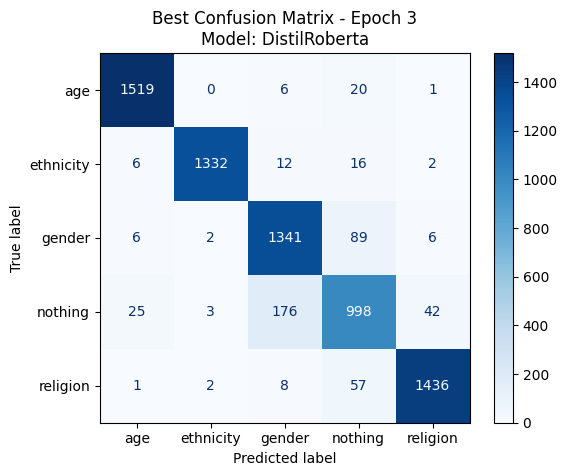

In [12]:
config = AutoConfig.from_pretrained("distilroberta-base", num_labels=num_labels)
model = CustomClassifier("distilroberta-base", config, class_weights=weights).to(device)

trainer_distil = Trainer(
          model=model, args=args,
          train_dataset=new_tr_distil, eval_dataset=new_val_distil,
          tokenizer=tokenizer_distil, data_collator=DataCollatorWithPadding(tokenizer_distil),
          compute_metrics=compute_metrics,
          callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)]
  )

result = trainer_distil.train()

time = round(result.metrics['train_runtime'] / 60,2)
print(f"training time of DistilRoberta is: {time} min")

best_model = trainer_distil.model
best_model_dir = os.path.join("models", "Distil_multiclass")
os.makedirs(best_model_dir, exist_ok=True)
os.rename(trainer_distil.state.best_model_checkpoint, best_model_dir)

save_model_pickle(best_model, best_model_dir, tokenizer_distil)

logs = pd.DataFrame(trainer_distil.state.log_history)
plot_confusion(logs, num_labels, "DistilRoberta")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-13-6e8128a5c03d>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_roberta = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,No log,0.237240,0.917675,0.919007,0.915740,0.915197,"[[1511, 1, 3, 30, 1], [9, 1297, 7, 51, 4], [9, 5, 1175, 241, 14], [39, 6, 43, 1094, 62], [3, 9, 7, 41, 1444]]"
2,1.222200,0.180025,0.936110,0.934609,0.934592,0.934158,"[[1482, 7, 5, 50, 2], [0, 1338, 7, 19, 4], [0, 2, 1297, 141, 4], [2, 5, 98, 1098, 41], [0, 5, 10, 52, 1437]]"
3,0.417300,0.174821,0.937095,0.934606,0.933754,0.934073,"[[1516, 2, 6, 21, 1], [2, 1341, 8, 12, 5], [6, 2, 1334, 94, 8], [24, 5, 144, 1030, 41], [3, 2, 8, 53, 1438]]"
4,0.335500,0.158488,0.942724,0.941552,0.941505,0.940739,"[[1509, 4, 2, 30, 1], [0, 1350, 5, 11, 2], [2, 2, 1265, 171, 4], [10, 6, 55, 1126, 47], [2, 3, 5, 45, 1449]]"


training time of Roberta is: 9.44 min


<Figure size 1000x800 with 0 Axes>

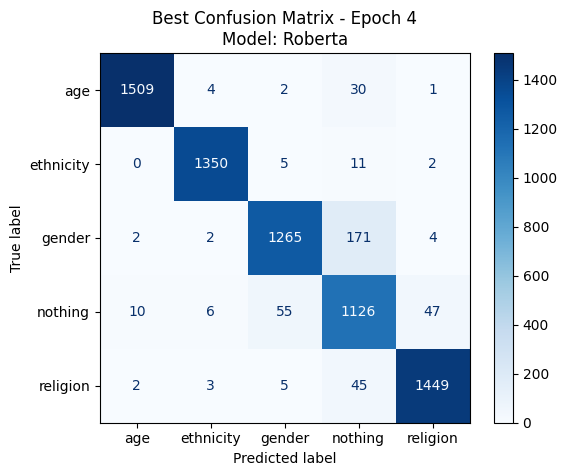

In [13]:
config = AutoConfig.from_pretrained("roberta-base", num_labels=num_labels)
model = CustomClassifier("roberta-base", config, class_weights=weights).to(device)

trainer_roberta = Trainer(
          model=model, args=args,
          train_dataset=new_tr_roberta, eval_dataset=new_val_roberta,
          tokenizer=tokenizer_roberta, data_collator=DataCollatorWithPadding(tokenizer_roberta),
          compute_metrics=compute_metrics,
          callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.01)]
  )

result = trainer_roberta.train()

time = round(result.metrics['train_runtime'] / 60,2)
print(f"training time of Roberta is: {time} min")

best_model = trainer_roberta.model
best_model_dir = os.path.join("models", "Roberta_multiclass")
os.makedirs(best_model_dir, exist_ok=True)
os.rename(trainer_roberta.state.best_model_checkpoint, best_model_dir)

save_model_pickle(best_model, best_model_dir, tokenizer_roberta)

logs = pd.DataFrame(trainer_roberta.state.log_history)
plot_confusion(logs, num_labels, "Roberta")